Esta sección aborda dos conceptos cruciales en el aprendizaje automático moderno: la **interpretabilidad** de los modelos (Caja Blanca vs. Caja Negra) y cómo los árboles calculan **probabilidades estimadas** en lugar de solo dar predicciones directas.



# Interpretación de Modelos: Caja Blanca frente a Caja Negra



Los árboles de decisión son intuitivos y sus decisiones son fáciles de interpretar. 

Este tipo de modelos suelen denominarse **modelos de caja blanca (white box models)**. 

Por el contrario, como verás más adelante, los bosques aleatorios (Random Forests) y las redes neuronales se consideran generalmente **modelos de caja negra (black box models)**. 

Estos últimos realizan excelentes predicciones y puedes verificar fácilmente los cálculos matemáticos que realizaron para llegar a ellas; sin embargo, por lo general es difícil explicar en términos sencillos *por qué* se tomó una decisión específica.



Por ejemplo, si una red neuronal identifica que una persona en particular aparece en una foto, es difícil saber qué elementos contribuyeron a esa predicción: 
* ¿Reconoció el modelo los ojos de esa persona? 
* ¿Su boca? 
* ¿Su nariz? 
* ¿Sus zapatos? 
* ¿O incluso el sofá en el que estaba sentada?



Por el contrario, los árboles de decisión proporcionan reglas de clasificación simples y agradables que incluso podrían aplicarse manualmente si fuera necesario (por ejemplo, para clasificar flores).



El campo del **Aprendizaje Automático Interpretable (Interpretable ML / XAI)** tiene como objetivo crear sistemas de Machine Learning que puedan explicar sus decisiones de una manera que los humanos puedan comprender. 

Esto es vital en muchos sectores:

* **Salud:** Permite a un médico revisar y validar un diagnóstico.
* **Finanzas:** Permite a los analistas comprender los riesgos financieros.
* **Sistema Judicial:** Garantiza que un humano tome la decisión legal final basada en evidencia clara.
* **Recursos Humanos:** Asegura que las decisiones de contratación o evaluación no estén sesgadas de forma oculta.



# Estimación de Probabilidades de Clase

Un árbol de decisión también puede estimar la probabilidad de que una instancia pertenezca a una clase particular $k$. 

Primero recorre el árbol para encontrar el nodo hoja correspondiente a esa instancia y luego devuelve la proporción de instancias de la clase $k$ dentro de las muestras de entrenamiento que llegaron a ese mismo nodo hoja.



Por ejemplo, supón que has encontrado una flor cuyos pétalos miden 5 cm de largo y 1.5 cm de ancho. 

El nodo hoja correspondiente es el nodo izquierdo de profundidad 2 (según los pasos anteriores), por lo que el árbol de decisión arroja las siguientes probabilidades:

* **0%** para *Iris setosa* ($\frac{0}{54}$)
* **90.7%** para *Iris versicolor* ($\frac{49}{54}$)
* **9.3%** para *Iris virginica* ($\frac{5}{54}$)

Si le pides al modelo que prediga la clase directamente, arrojará *Iris versicolor* (clase 1) porque tiene la probabilidad más alta. Comprobémoslo con código:



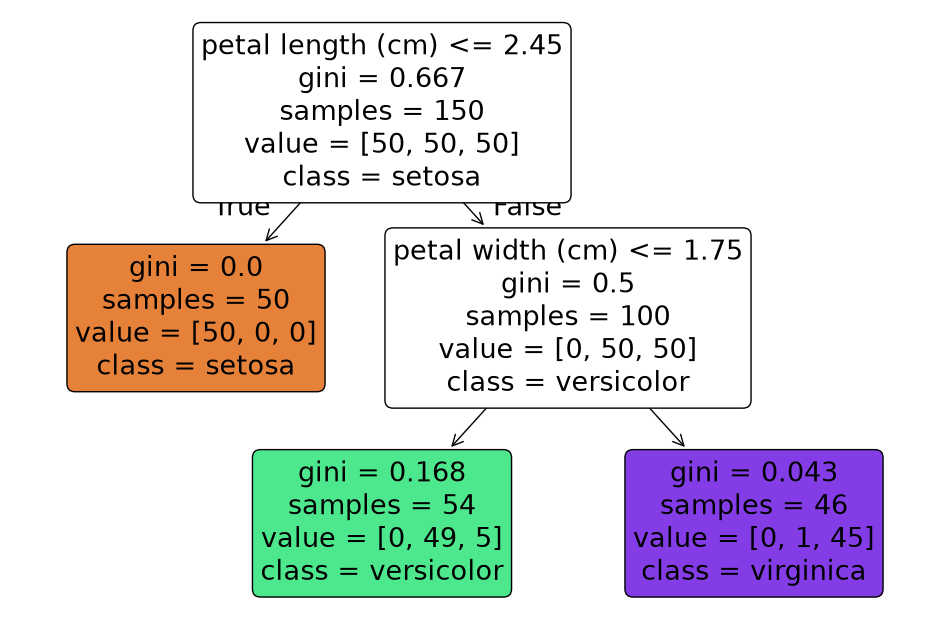

In [2]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
# Cargar el conjunto de datos Iris
iris = load_iris()
X = iris.data[:, 2:]  # Usar solo las características de longitud y ancho del pétalo
y = iris.target
# Entrenar el árbol de decisión
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X, y)
# Visualizar el árbol de decisión
plt.figure(figsize=(12, 8))
plot_tree(
    tree_clf,
    feature_names=iris.feature_names[2:],
    class_names=iris.target_names,
     filled=True,
     rounded=True
)
plt.savefig(r"C:\Users\marco\Downloads\iris_tree.png", dpi=300)
plt.show()

In [3]:
tree_clf.predict_proba([[5, 1.5]]).round(3)



array([[0.   , 0.907, 0.093]])

In [4]:
tree_clf.predict([[5, 1.5]])


array([1])


Ten en cuenta que **las probabilidades estimadas serán idénticas en cualquier otro punto dentro de la misma región** (el rectángulo inferior derecho de las fronteras de decisión). 

Por ejemplo, si los pétalos midieran 6 cm de largo y 1.5 cm de ancho, la probabilidad devuelta sería exactamente la misma, a pesar de que visualmente parezca obvio que a mayor longitud es mucho más probable que se trate de una *Iris virginica*.

---



## 2. Correcciones Técnicas Importantes

* **Advertencia de Scikit-Learn en versiones modernas:** Si ejecutas `tree_clf.predict([[5, 1.5]])` directamente pasando una lista normal, las versiones recientes de Scikit-Learn mostrarán un *UserWarning* indicando que las características no tienen nombres válidos (porque el modelo fue entrenado usando un DataFrame de Pandas con nombres de columnas como `"petal length (cm)"`). 

Para evitar este mensaje de advertencia visual, es una buena práctica pasar los datos usando la estructura correcta o mediante un array de NumPy.


* **Limitación por "escalones":** El texto destaca algo vital que debes recordar: **los árboles de decisión asignan la misma probabilidad a toda una región geográfica**, sin importar si estás en el centro de la región o justo en el borde de corte. No tienen transiciones suaves como una regresión logística.




## 3. Scripts de Python para Ejemplificar y Visualizar



### Script 1: Comprobación de Probabilidades (Código Limpio)

Este script entrena el modelo de manera correcta y calcula las probabilidades exactas descritas en el libro para la flor de (5cm, 1.5cm) y otra más larga en la misma zona.


In [5]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

# 1. Cargar y estructurar datos con nombres de columnas para evitar warnings
iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]]
y = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X, y)

# 2. Crear las muestras simuladas usando DataFrames (mismos nombres de columnas)
flor_1 = pd.DataFrame([[5, 1.5]], columns=X.columns)
flor_2 = pd.DataFrame([[6, 1.5]], columns=X.columns) # Más larga, misma región

print("--- Flor 1 (5 cm de largo, 1.5 cm de ancho) ---")
print(f"Probabilidades por clase: {tree_clf.predict_proba(flor_1).round(3)}")
print(f"Clase predicha: {iris.target_names[tree_clf.predict(flor_1)[0]]}\n")

print("--- Flor 2 (6 cm de largo, 1.5 cm de ancho) ---")
print(f"Probabilidades por clase: {tree_clf.predict_proba(flor_2).round(3)}")
print(f"Clase predicha: {iris.target_names[tree_clf.predict(flor_2)[0]]}")
print("> Nota cómo las probabilidades son idénticas a pesar del cambio de tamaño.")


--- Flor 1 (5 cm de largo, 1.5 cm de ancho) ---
Probabilidades por clase: [[0.    0.907 0.093]]
Clase predicha: versicolor

--- Flor 2 (6 cm de largo, 1.5 cm de ancho) ---
Probabilidades por clase: [[0.    0.907 0.093]]
Clase predicha: versicolor
> Nota cómo las probabilidades son idénticas a pesar del cambio de tamaño.



# Script 2: Visualización en 3D de las Probabilidades (El efecto "Caja Blanca / Escalón")

Para comprender realmente por qué las probabilidades son idénticas en toda la región, este script genera un mapa tridimensional. 

Verás cómo la probabilidad de ser *Iris versicolor* cambia drásticamente en forma de "escalones" planos y rígidos debido a las reglas lógicas del árbol.



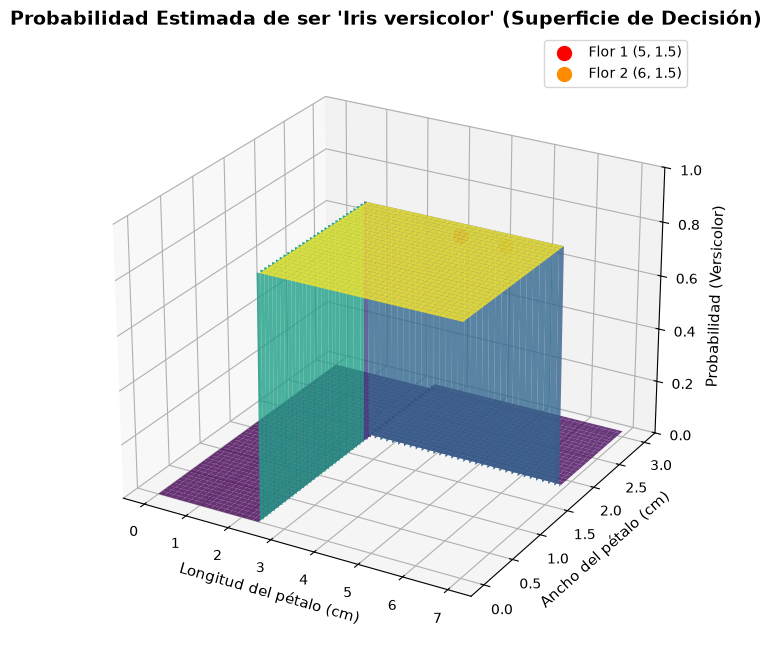

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

# Configurar datos y modelo
iris = load_iris()
X = iris.data[:, [2, 3]] # largo y ancho del pétalo
y = iris.target
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X, y)

# Crear una malla densa de puntos en el espacio
x_min, x_max = 0, 7
y_min, y_max = 0, 3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

# Calcular las probabilidades de que sea 'Iris versicolor' (Clase 1) para cada punto de la malla
Z_prob = tree_clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z_prob = Z_prob.reshape(xx.shape)

# Graficar la superficie en 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(xx, yy, Z_prob, cmap='viridis', edgecolor='none', alpha=0.8)

# Resaltar los dos puntos del ejemplo del libro
# Flor 1 (5, 1.5) -> Probabilidad ~0.907
ax.scatter([5], [1.5], [0.907], color='red', s=100, label='Flor 1 (5, 1.5)', zorder=5)
# Flor 2 (6, 1.5) -> Probabilidad ~0.907
ax.scatter([6], [1.5], [0.907], color='darkorange', s=100, label='Flor 2 (6, 1.5)', zorder=5)

# Personalización del gráfico
ax.set_title("Probabilidad Estimada de ser 'Iris versicolor' (Superficie de Decisión)", fontsize=14, fontweight='bold')
ax.set_xlabel("Longitud del pétalo (cm)", fontsize=11)
ax.set_ylabel("Ancho del pétalo (cm)", fontsize=11)
ax.set_zlabel("Probabilidad (Versicolor)", fontsize=11)
ax.set_zlim(0, 1)
ax.view_init(elev=25, azim=-60) # Ajustar el ángulo de visión para apreciar los escalones
plt.legend()
plt.savefig(r"C:\Users\marco\Downloads\iris_surface.png", dpi=300)
plt.show()



# ¿Qué concluyes al ver la gráfica 3D?



Al ejecutar el segundo código verás una meseta o "escalón" plano elevado. El punto rojo (Flor 1) y el punto naranja (Flor 2) están sobre la misma superficie plana. 

Al ser un modelo de caja blanca basado puramente en límites duros (como un diagrama de flujo con `if/else`), el algoritmo no suaviza las probabilidades en las fronteras, reflejando de forma transparente la lógica del algoritmo CART.